# 01 - Structural VAR: Cholesky and AB Model Identification (SOLUTION)

This is the **complete solution** notebook with all exercises resolved and outputs saved.

## Topics covered

1. **Cholesky decomposition** (recursive identification)
2. **AB model** with explicit short-run restrictions
3. **Exercise 1**: Cholesky with alternative ordering
4. **Exercise 2**: AB model with non-recursive restrictions
5. **Quantitative comparison** between identification schemes

---

## From Reduced Form to Structural Form

A **reduced-form VAR(p)** is:

$$Y_t = c + A_1 Y_{t-1} + A_2 Y_{t-2} + \cdots + A_p Y_{t-p} + u_t, \quad u_t \sim N(0, \Sigma_u)$$

The **structural form** links reduced-form residuals to structural shocks:

$$u_t = B_0^{-1} \varepsilon_t, \quad \varepsilon_t \sim N(0, I_K)$$

We need **at least** $K(K-1)/2$ additional restrictions to achieve identification.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import sys
import os

from chronobox.models import VAR, SVAR

sys.path.insert(0, os.path.join("..", "utils"))
from plot_helpers import plot_structural_irf, plot_irf_comparison
from data_generators import generate_monetary_policy

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
np.set_printoptions(precision=4, suppress=True)

# Ensure output directories exist
os.makedirs(os.path.join("..", "outputs"), exist_ok=True)

print("All imports loaded successfully.")

All imports loaded successfully.


## 1. Loading the US Macro Dataset

Quarterly US macroeconomic data with 4 variables in **CEE ordering**:

1. **GDP** - slow-moving, does not respond within the quarter
2. **Inflation** - responds to output gap but not to policy within the quarter
3. **Fed Funds** - central bank observes GDP and inflation before setting rate
4. **Unemployment** - responds to all other variables contemporaneously

In [2]:
# Load US macro quarterly dataset
data_path = os.path.join("..", "data", "us_macro_quarterly.csv")
df = pd.read_csv(data_path, parse_dates=["date"])
df.set_index("date", inplace=True)

var_names = ["gdp", "inflation", "fed_funds", "unemployment"]
endog = df[var_names].values

print(f"Dataset shape: {df.shape}")
print(f"Period: {df.index[0]} to {df.index[-1]}")
print(f"\nDescriptive statistics:")
df[var_names].describe().round(3)

Dataset shape: (200, 4)
Period: 1975-01-01 00:00:00 to 2024-10-01 00:00:00

Descriptive statistics:


,gdp,inflation,fed_funds,unemployment
count,200.000,200.000,200.000,200.000
mean,3.289,3.506,6.066,9.526
std,0.734,0.593,0.801,0.704
min,1.437,2.100,4.271,7.819
25%,2.772,3.100,5.467,9.042
50%,3.280,3.447,6.056,9.431
75%,3.832,3.876,6.659,10.007
max,5.466,5.359,7.950,11.262


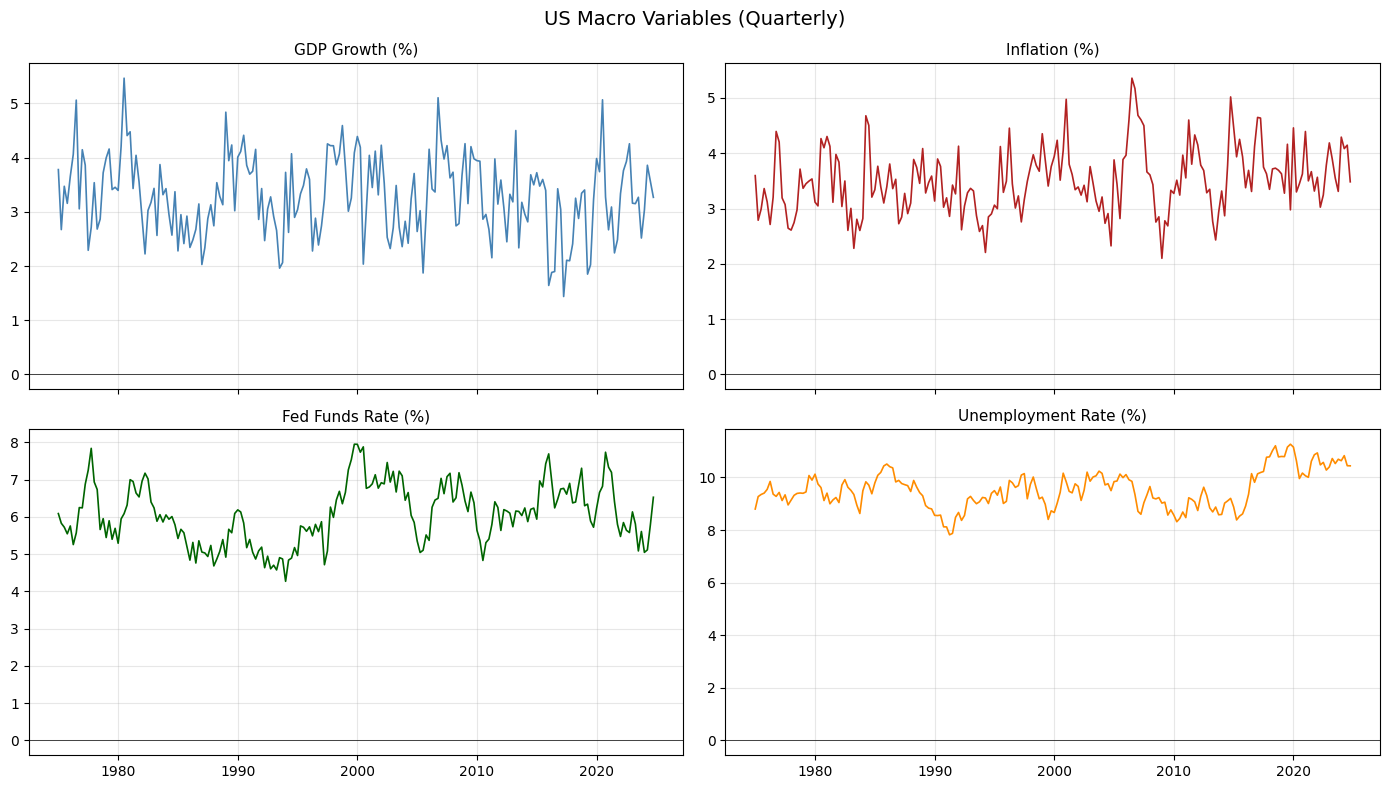

In [3]:
# Visualize the data
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
titles = ["GDP Growth (%)", "Inflation (%)", "Fed Funds Rate (%)", "Unemployment Rate (%)"]
colors = ["steelblue", "firebrick", "darkgreen", "darkorange"]

for i, (ax, name, title, color) in enumerate(zip(axes.flat, var_names, titles, colors)):
    ax.plot(df.index, df[name], color=color, linewidth=1.2)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color="black", linewidth=0.5)

plt.suptitle("US Macro Variables (Quarterly)", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Fitting the Reduced-Form VAR

In [4]:
# Fit reduced-form VAR(4)
var_model = VAR(lags=4, trend="c")
var_results = var_model.fit(endog)

print(f"VAR({var_results.k_ar}) fitted")
print(f"Number of observations: {var_results.nobs}")
print(f"Number of variables: {var_results.neqs}")
print(f"\nReduced-form residual covariance (Sigma_u):")
print(var_results.sigma_u.round(4))

# Residual correlation matrix
corr = np.corrcoef(var_results.resid.T)
print(f"\nResidual correlation matrix:")
print(pd.DataFrame(corr, index=var_names, columns=var_names).round(3))

VAR(4) fitted
Number of observations: 196
Number of variables: 4

Reduced-form residual covariance (Sigma_u):
[[ 0.4438  0.0548 -0.0078 -0.069 ]
 [ 0.0548  0.2523  0.0202  0.0328]
 [-0.0078  0.0202  0.1647 -0.0209]
 [-0.069   0.0328 -0.0209  0.0956]]

Residual correlation matrix:
                gdp  inflation  fed_funds  unemployment
gdp           1.000      0.164     -0.029        -0.335
inflation     0.164      1.000      0.099         0.211
fed_funds    -0.029      0.099      1.000        -0.167
unemployment -0.335      0.211     -0.167         1.000


## 3. Cholesky Identification

The Cholesky decomposition $\Sigma_u = PP'$ where $P$ is lower triangular.
Setting $B_0^{-1} = P$ imposes a **recursive (triangular) structure** with
$K(K-1)/2 = 6$ zero restrictions.

In [5]:
# SVAR with Cholesky identification
svar_cholesky = SVAR(var_results, method="cholesky")
results_cholesky = svar_cholesky.fit()

print(f"Identification method: {results_cholesky.method}")
print(f"\nStructural impact matrix (B0_inv = Cholesky factor P):")
print(pd.DataFrame(
    results_cholesky.A0_inv.round(4),
    index=var_names, columns=[f"shock_{v}" for v in var_names]
))

# Verify reconstruction
reconstructed = results_cholesky.A0_inv @ results_cholesky.A0_inv.T
print(f"\nReconstruction check ||Sigma_u - P@P'||: {np.linalg.norm(var_results.sigma_u - reconstructed):.2e}")

Identification method: cholesky

Structural impact matrix (B0_inv = Cholesky factor P):
              shock_gdp  shock_inflation  shock_fed_funds  shock_unemployment
gdp              0.6662           0.0000           0.0000              0.0000
inflation        0.0822           0.4956           0.0000              0.0000
fed_funds       -0.0117           0.0428           0.4035              0.0000
unemployment    -0.1036           0.0833          -0.0636              0.2717

Reconstruction check ||Sigma_u - P@P'||: 6.25e-17


IRF shape: (21, 4, 4)  (periods+1, K_response, K_shock)


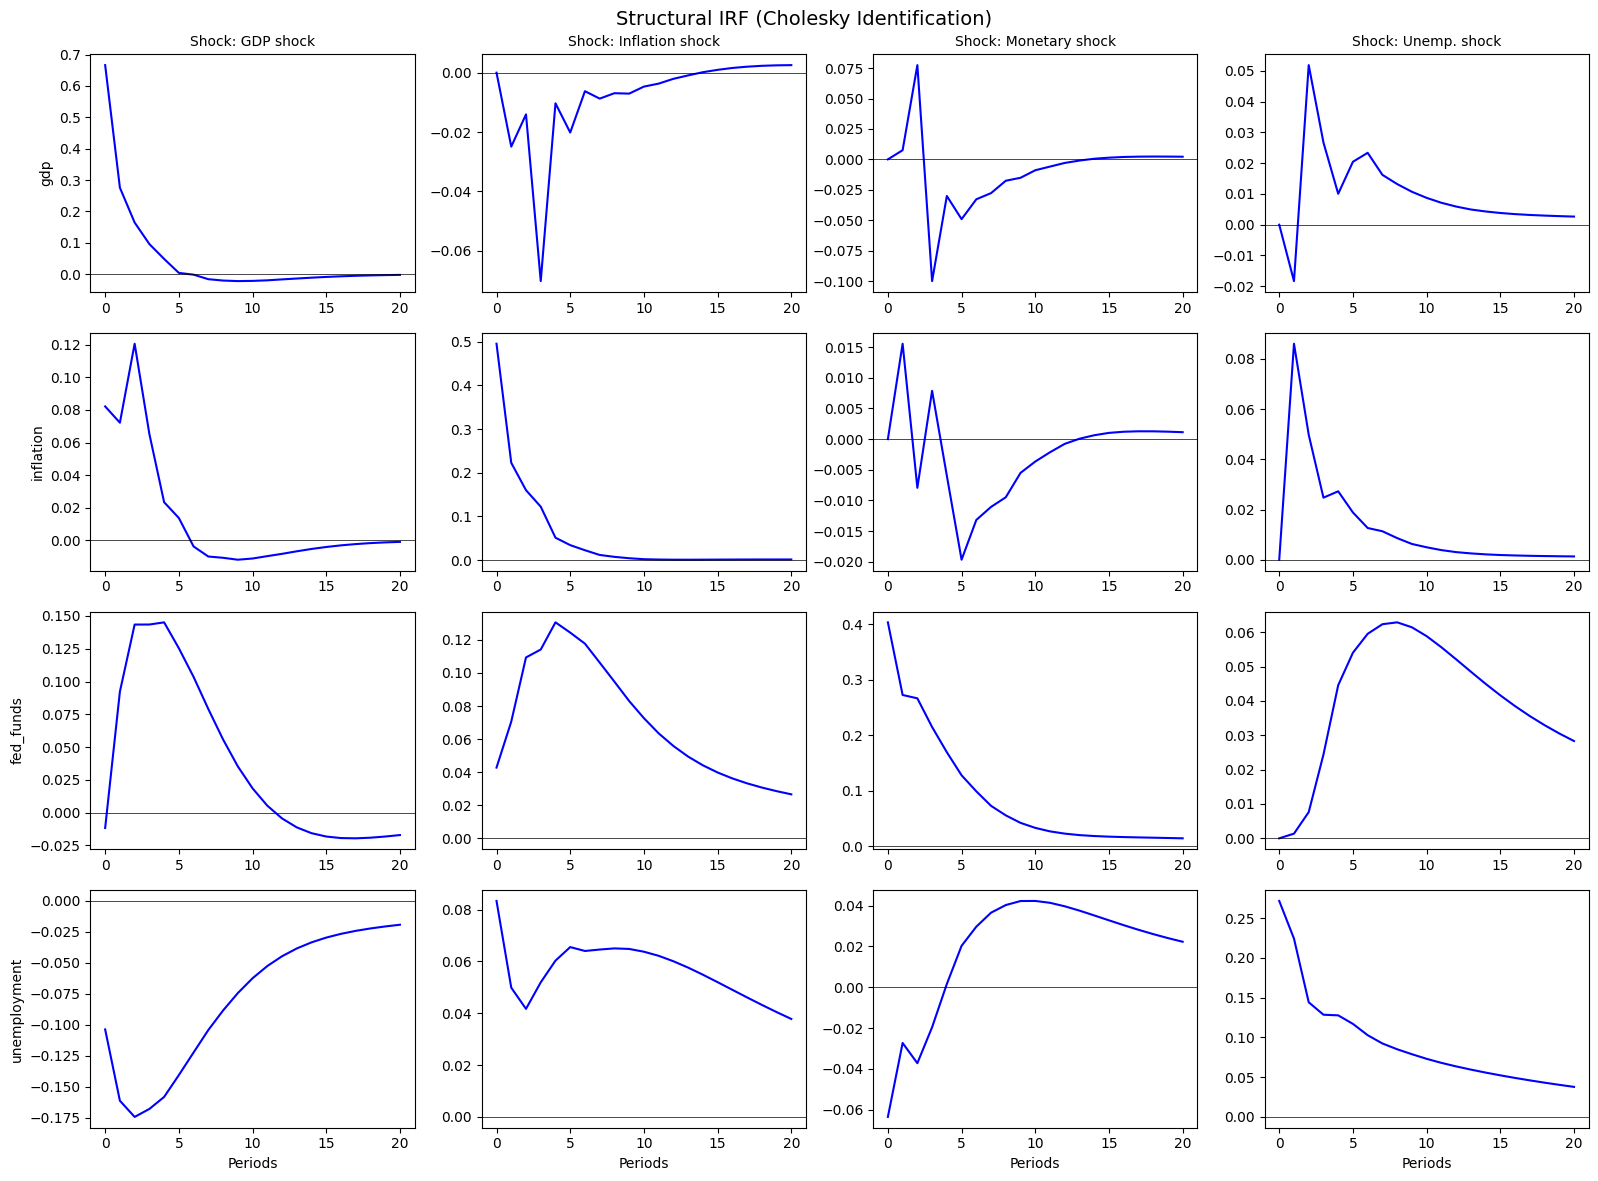

In [6]:
# Compute structural IRFs (20 quarters = 5 years)
irf_cholesky = results_cholesky.irf(periods=20)
print(f"IRF shape: {irf_cholesky.shape}  (periods+1, K_response, K_shock)")

shock_names = ["GDP shock", "Inflation shock", "Monetary shock", "Unemp. shock"]
fig = plot_structural_irf(
    irf_cholesky,
    variable_names=var_names,
    shock_names=shock_names,
    title="Structural IRF (Cholesky Identification)",
    figsize=(16, 12),
)
plt.savefig(os.path.join("..", "outputs", "svar_cholesky_irf_all.png"), bbox_inches="tight")
plt.show()

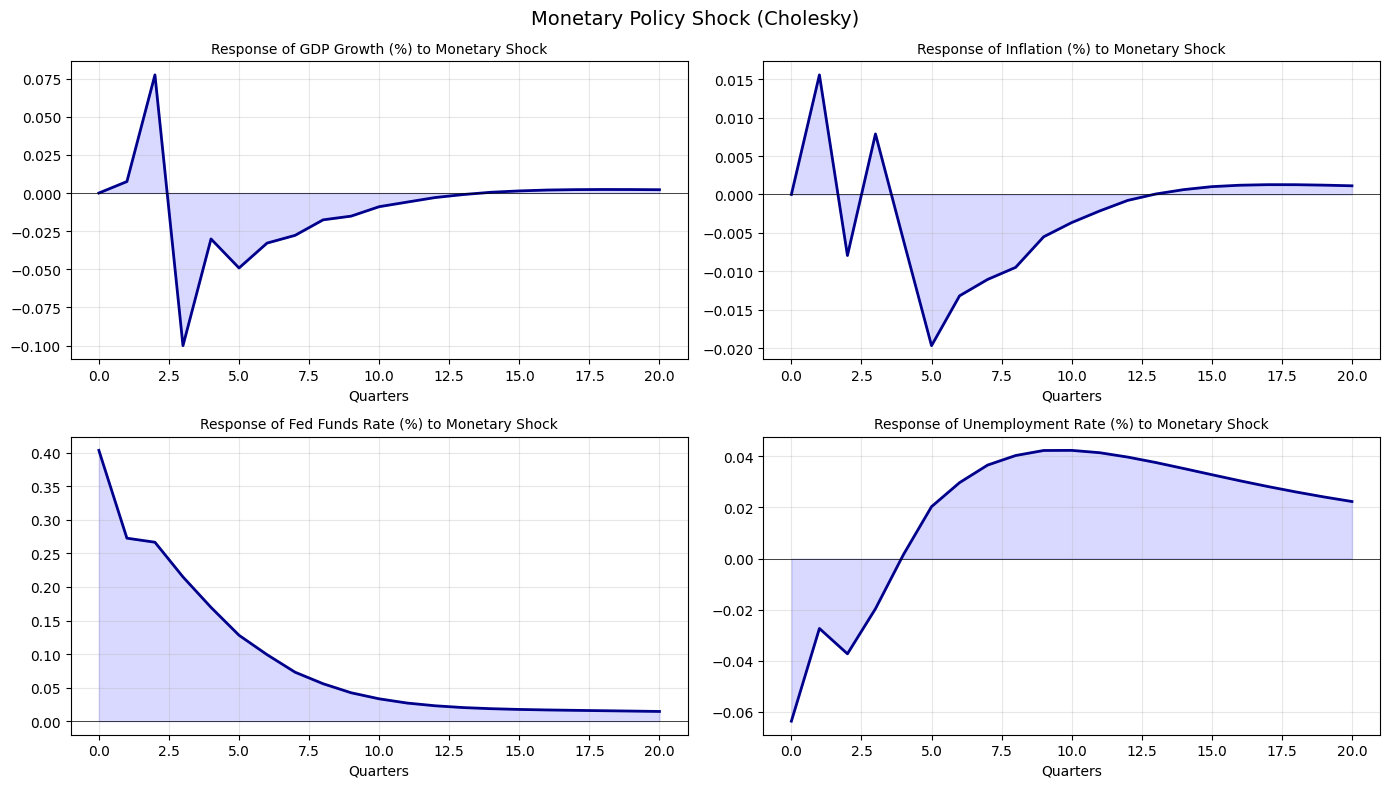

In [7]:
# Focus on the monetary policy shock
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
horizons = np.arange(irf_cholesky.shape[0])
monetary_shock_idx = 2

for i, (ax, name, title) in enumerate(zip(axes.flat, var_names, titles)):
    ax.plot(horizons, irf_cholesky[:, i, monetary_shock_idx],
            color="darkblue", linewidth=2)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.fill_between(horizons, 0, irf_cholesky[:, i, monetary_shock_idx],
                    alpha=0.15, color="blue")
    ax.set_title(f"Response of {title} to Monetary Shock", fontsize=10)
    ax.set_xlabel("Quarters")
    ax.grid(True, alpha=0.3)

plt.suptitle("Monetary Policy Shock (Cholesky)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "svar_cholesky_monetary_shock.png"), bbox_inches="tight")
plt.show()

FEVD shape: (21, 4, 4)  (periods+1, K_response, K_shock)


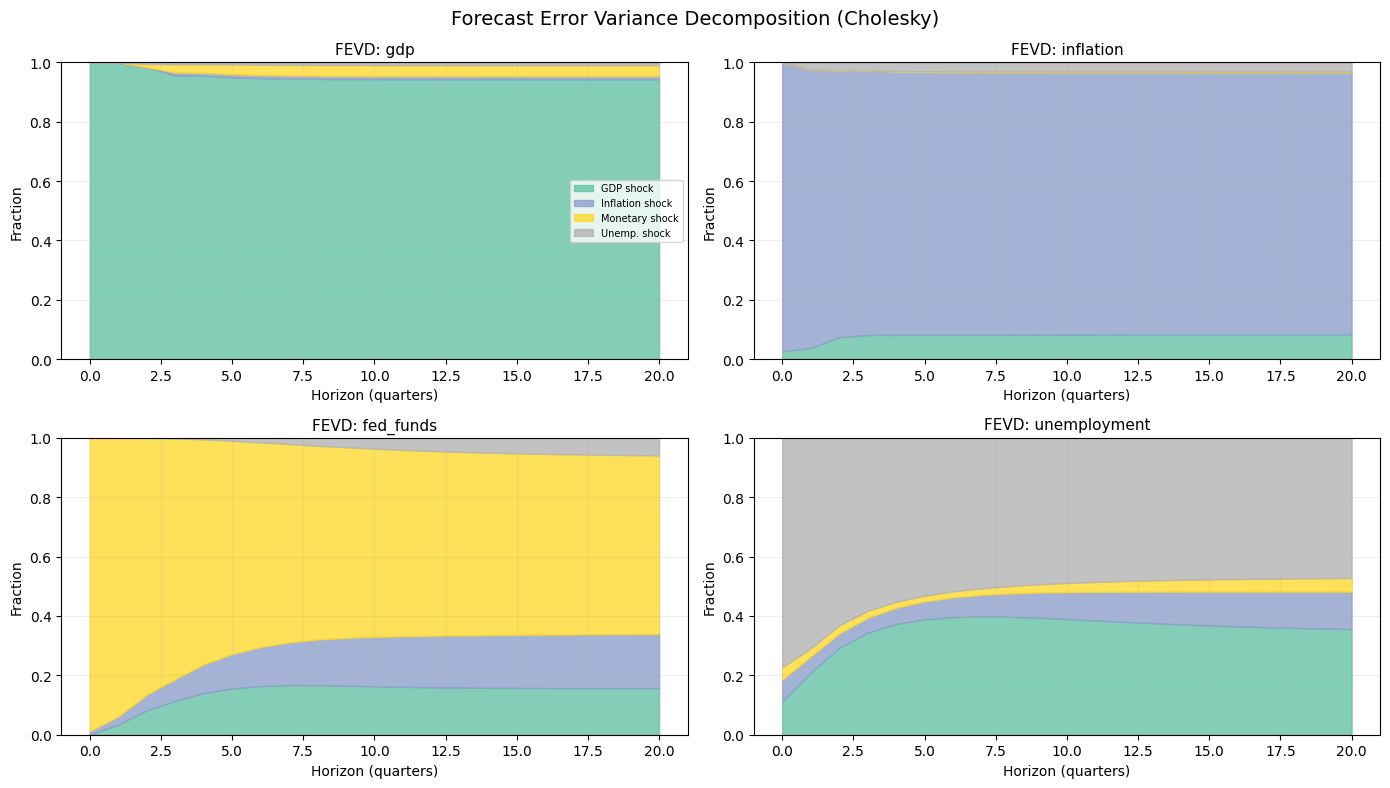

In [8]:
# FEVD under Cholesky identification
fevd_cholesky = results_cholesky.fevd(periods=20)
print(f"FEVD shape: {fevd_cholesky.shape}  (periods+1, K_response, K_shock)")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
cmap = plt.cm.Set2

for i, (ax, name) in enumerate(zip(axes.flat, var_names)):
    bottom = np.zeros(fevd_cholesky.shape[0])
    for j in range(len(var_names)):
        ax.fill_between(
            np.arange(fevd_cholesky.shape[0]),
            bottom, bottom + fevd_cholesky[:, i, j],
            label=shock_names[j], alpha=0.8, color=cmap(j / 3)
        )
        bottom += fevd_cholesky[:, i, j]
    ax.set_title(f"FEVD: {name}", fontsize=11)
    ax.set_xlabel("Horizon (quarters)")
    ax.set_ylabel("Fraction")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.2)
    if i == 0:
        ax.legend(fontsize=7, loc="center right")

plt.suptitle("Forecast Error Variance Decomposition (Cholesky)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "svar_cholesky_fevd.png"), bbox_inches="tight")
plt.show()

## 4. AB Model Identification

The AB model: $Au_t = B\varepsilon_t$ with restrictions:
- A[0,:] = [1, 0, 0, 0] — GDP exogenous
- A[1,:] = [free, 1, 0, 0] — Inflation responds to GDP
- A[2,:] = [free, free, 1, 0] — Taylor rule
- A[3,:] = [free, 0, 0, 1] — Unemployment responds to GDP
- B = diagonal (free)

In [9]:
K = 4

A_mat = np.array([
    [1.0,     0.0,     0.0,     0.0    ],
    [np.nan,  1.0,     0.0,     0.0    ],
    [np.nan,  np.nan,  1.0,     0.0    ],
    [np.nan,  0.0,     0.0,     1.0    ],
])

B_mat = np.array([
    [np.nan, 0.0,    0.0,    0.0   ],
    [0.0,    np.nan, 0.0,    0.0   ],
    [0.0,    0.0,    np.nan, 0.0   ],
    [0.0,    0.0,    0.0,    np.nan],
])

print("A matrix template (nan = free parameter):")
print(A_mat)
print(f"\nFree parameters in A: {np.isnan(A_mat).sum()}")
print(f"Free parameters in B: {np.isnan(B_mat).sum()}")
print(f"Total free parameters: {np.isnan(A_mat).sum() + np.isnan(B_mat).sum()}")
print(f"Available equations (unique elements in Sigma_u): {K*(K+1)//2}")
print(f"Just-identified: {np.isnan(A_mat).sum() + np.isnan(B_mat).sum() == K*(K+1)//2}")

A matrix template (nan = free parameter):
[[ 1.  0.  0.  0.]
 [nan  1.  0.  0.]
 [nan nan  1.  0.]
 [nan  0.  0.  1.]]

Free parameters in A: 4
Free parameters in B: 4
Total free parameters: 8
Available equations (unique elements in Sigma_u): 10
Just-identified: False


In [10]:
# Fit the AB model
svar_ab = SVAR(var_results, method="ab", a_mat=A_mat, b_mat=B_mat)
results_ab = svar_ab.fit()

print(f"Identification method: {results_ab.method}")
print(f"\nEstimated A matrix:")
print(pd.DataFrame(results_ab.A0.round(4), index=var_names, columns=var_names))
print(f"\nEstimated B matrix:")
print(pd.DataFrame(results_ab.B.round(4), index=var_names, columns=var_names))
print(f"\nStructural impact matrix (A^{{-1}}B):")
print(pd.DataFrame(
    results_ab.A0_inv.round(4),
    index=var_names, columns=[f"shock_{v}" for v in var_names]
))

Identification method: ab

Estimated A matrix:
                 gdp  inflation  fed_funds  unemployment
gdp           1.0000     0.0000        0.0           0.0
inflation    -0.1234     1.0000        0.0           0.0
fed_funds     0.0282    -0.0863        1.0           0.0
unemployment  0.1555     0.0000        0.0           1.0

Estimated B matrix:
                 gdp  inflation  fed_funds  unemployment
gdp           0.6662     0.0000     0.0000        0.0000
inflation     0.0000     0.4956     0.0000        0.0000
fed_funds     0.0000     0.0000     0.4035        0.0000
unemployment  0.0000     0.0000     0.0000        0.2913

Structural impact matrix (A^{-1}B):
              shock_gdp  shock_inflation  shock_fed_funds  shock_unemployment
gdp              0.6662           0.0000           0.0000              0.0000
inflation        0.0822           0.4956           0.0000              0.0000
fed_funds       -0.0117           0.0428           0.4035              0.0000
unemployment 

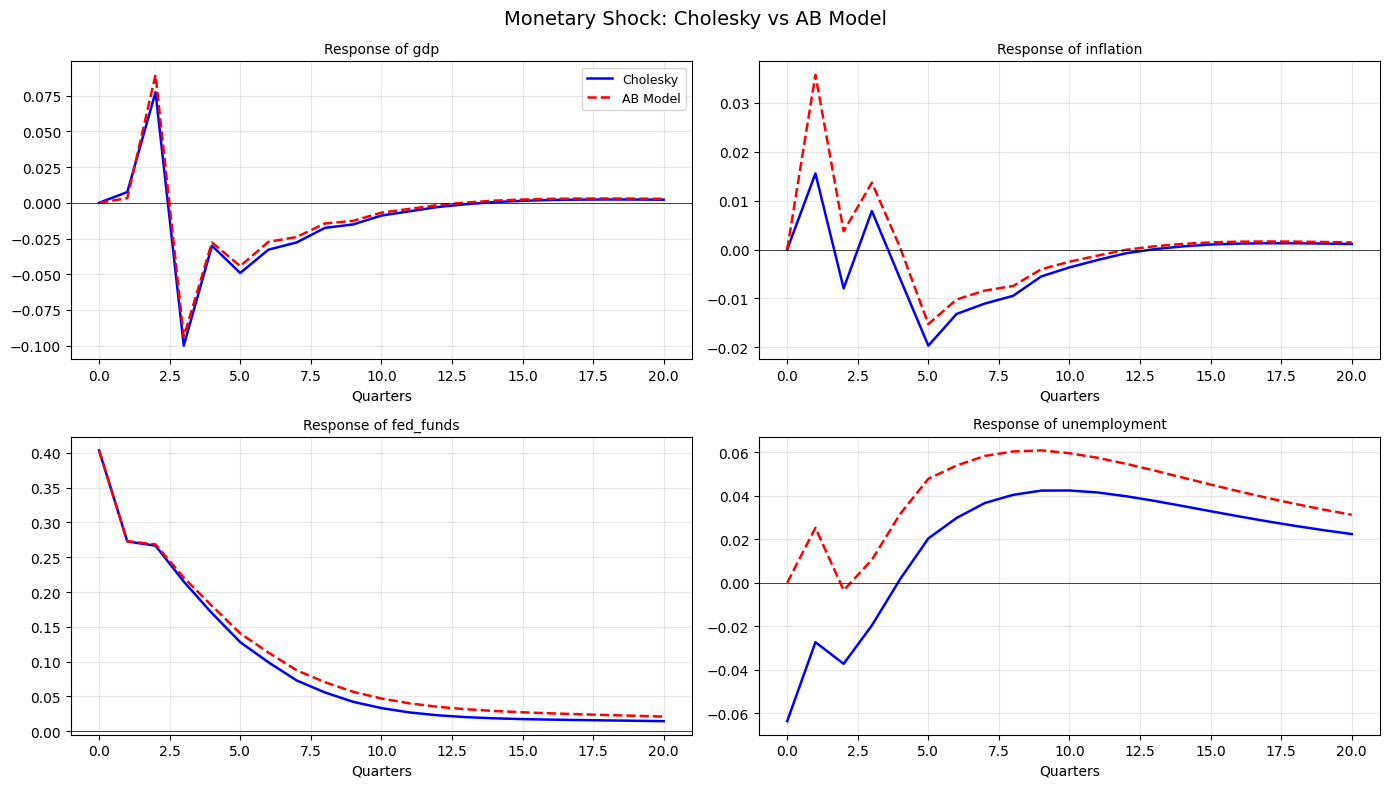

In [11]:
# Compare Cholesky vs AB for the monetary policy shock
irf_ab = results_ab.irf(periods=20)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (ax, name, title) in enumerate(zip(axes.flat, var_names, titles)):
    ax.plot(horizons, irf_cholesky[:, i, monetary_shock_idx],
            "b-", linewidth=1.8, label="Cholesky")
    ax.plot(horizons, irf_ab[:, i, monetary_shock_idx],
            "r--", linewidth=1.8, label="AB Model")
    ax.axhline(0, color="k", linewidth=0.5)
    ax.set_title(f"Response of {name}", fontsize=10)
    ax.set_xlabel("Quarters")
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=9)

plt.suptitle("Monetary Shock: Cholesky vs AB Model", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "svar_cholesky_vs_ab.png"), bbox_inches="tight")
plt.show()

Structural shocks shape: (196, 4)

Correlation of structural shocks (should be ~identity):
                 GDP shock  Inflation shock  Monetary shock  Unemp. shock
GDP shock              1.0              0.0            -0.0           0.0
Inflation shock        0.0              1.0            -0.0          -0.0
Monetary shock        -0.0             -0.0             1.0           0.0
Unemp. shock           0.0             -0.0             0.0           1.0


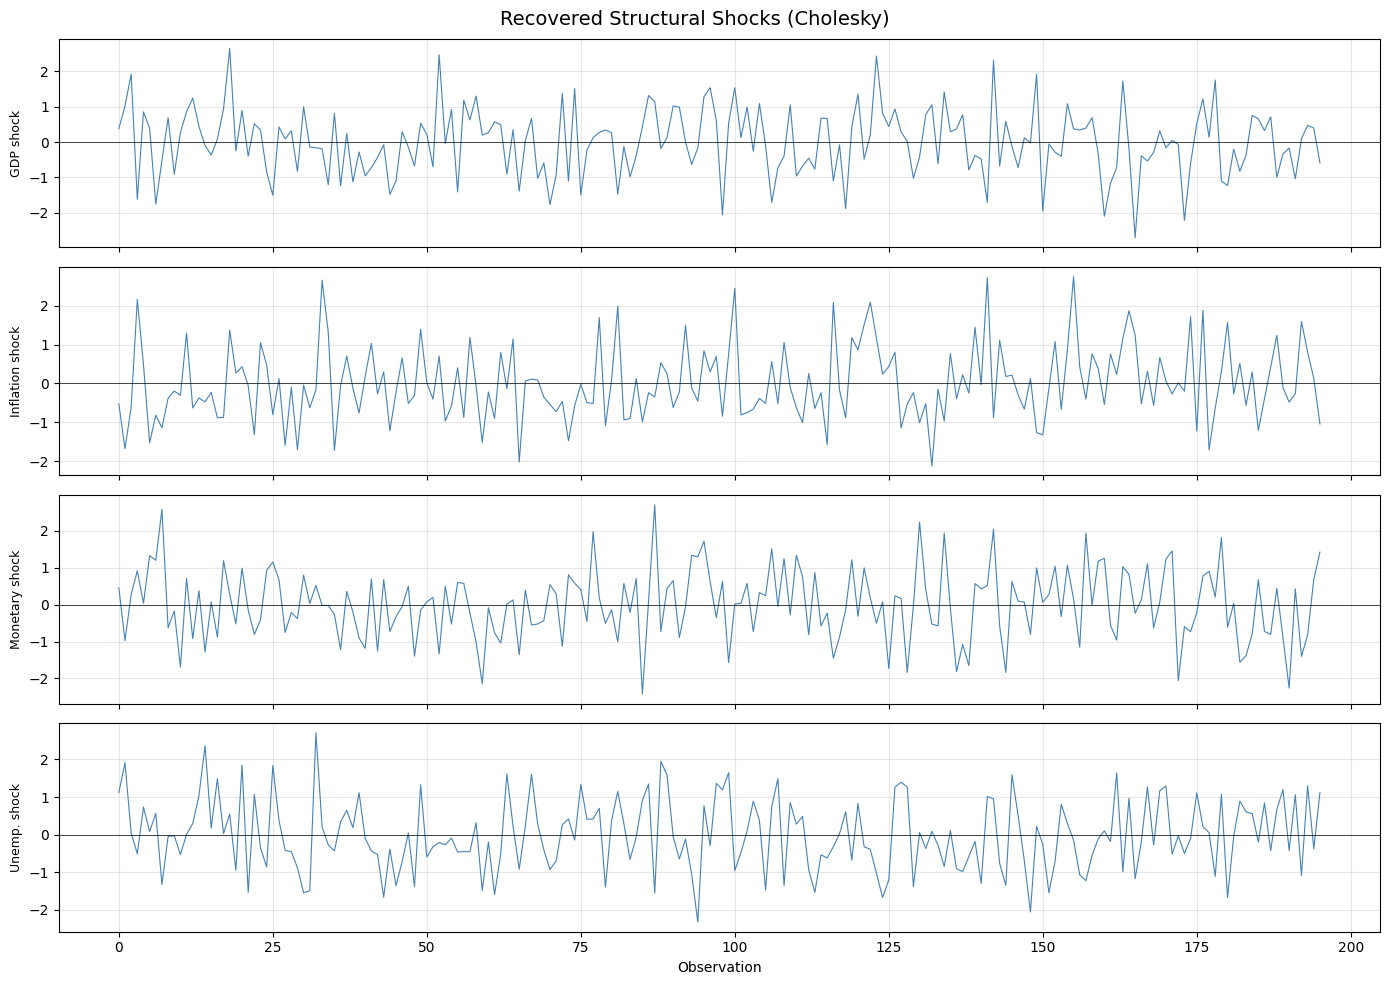

In [12]:
# Structural shocks verification
structural_shocks = results_cholesky.structural_shocks
print(f"Structural shocks shape: {structural_shocks.shape}")

shock_corr = np.corrcoef(structural_shocks.T)
print(f"\nCorrelation of structural shocks (should be ~identity):")
print(pd.DataFrame(shock_corr.round(4), index=shock_names, columns=shock_names))

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for i, (ax, name) in enumerate(zip(axes, shock_names)):
    ax.plot(structural_shocks[:, i], color="steelblue", linewidth=0.8)
    ax.axhline(0, color="k", linewidth=0.5)
    ax.set_ylabel(name, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Observation")
plt.suptitle("Recovered Structural Shocks (Cholesky)", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Validation with Synthetic Data

True structural impact matrix (B0_inv):
               output_gap  inflation  interest_rate
output_gap            1.0        0.0            0.0
inflation             0.3        0.8            0.0
interest_rate         0.2        0.3            0.6

Estimated B0_inv:
               output_gap  inflation  interest_rate
output_gap         1.0049     0.0000         0.0000
inflation          0.2892     0.7964         0.0000
interest_rate      0.1967     0.3293         0.6292


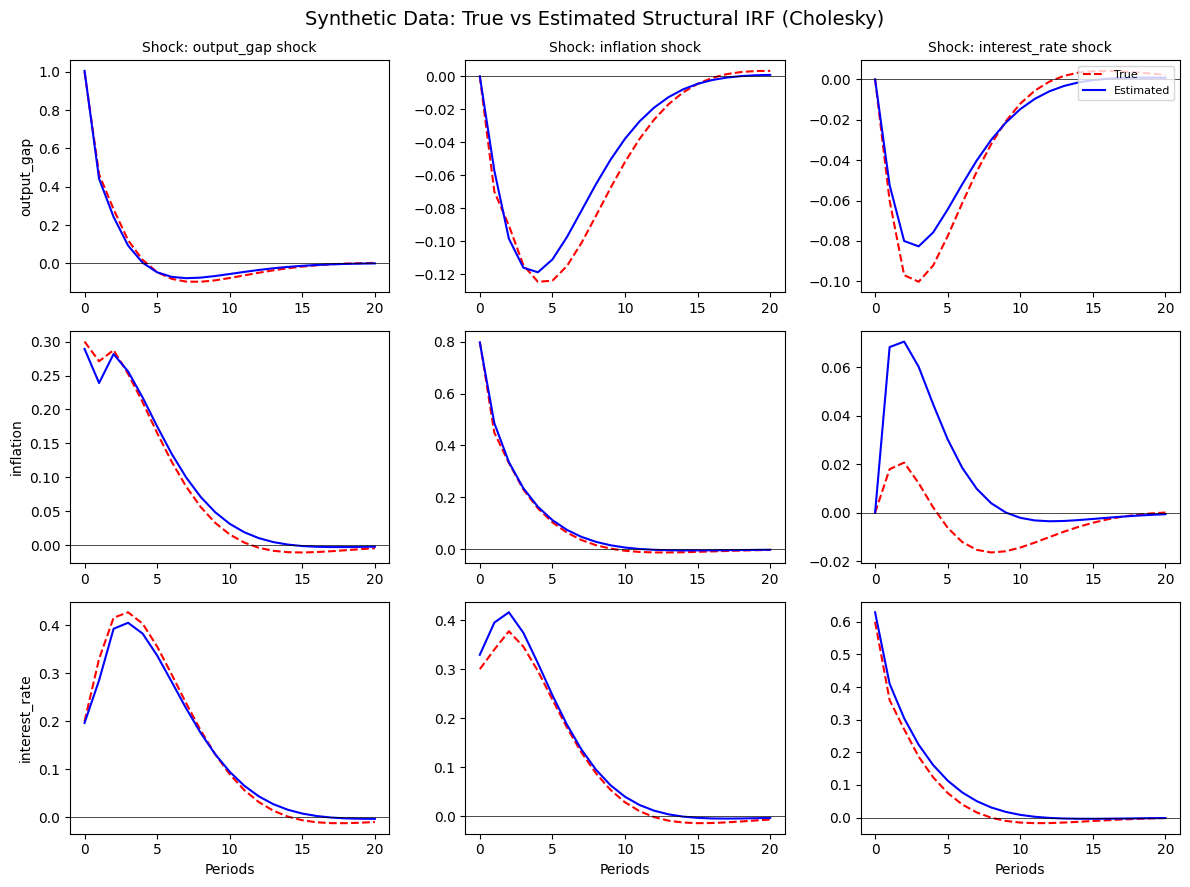

In [13]:
# Generate synthetic monetary policy data with known DGP
synth_data, true_params = generate_monetary_policy(n=500, seed=42)
synth_names = true_params["variable_names"]

print(f"True structural impact matrix (B0_inv):")
print(pd.DataFrame(true_params["B0_inv"].round(4),
                    index=synth_names, columns=synth_names))

# Fit VAR and SVAR on synthetic data
var_synth = VAR(lags=2, trend="c")
var_synth_res = var_synth.fit(synth_data)

svar_synth = SVAR(var_synth_res, method="cholesky")
res_synth = svar_synth.fit()

print(f"\nEstimated B0_inv:")
print(pd.DataFrame(res_synth.A0_inv.round(4), index=synth_names, columns=synth_names))

# Compute true IRFs
irf_true_synth = np.zeros((21, 3, 3))
Phi = [np.eye(3)]
A_list = [true_params["A1"], true_params["A2"]]
for h in range(1, 21):
    phi_h = np.zeros((3, 3))
    for j, A in enumerate(A_list):
        if h - j - 1 >= 0:
            phi_h += A @ Phi[h - j - 1]
    Phi.append(phi_h)
for h in range(21):
    irf_true_synth[h] = Phi[h] @ true_params["B0_inv"]

irf_est_synth = res_synth.irf(periods=20)

fig = plot_irf_comparison(
    irf_true_synth, irf_est_synth,
    variable_names=synth_names,
    shock_names=[f"{n} shock" for n in synth_names],
    title="Synthetic Data: True vs Estimated Structural IRF (Cholesky)",
)
plt.savefig(os.path.join("..", "outputs", "svar_validation_cholesky.png"), bbox_inches="tight")
plt.show()

---

## Exercicio 1: Cholesky com ordering alternativo (SOLUCAO)

Reordenamos as variaveis como `[inflation, gdp, fed_funds, unemployment]` — colocando
inflacao como a variavel mais exogena. Isso reflete uma visao onde a inflacao e
determinada por fatores de custo (cost-push) e nao responde ao ciclo no curto prazo.

In [14]:
# Exercicio 1: Cholesky com ordering alternativo
alt_names = ["inflation", "gdp", "fed_funds", "unemployment"]
endog_alt = df[alt_names].values

# Fit VAR(4) with alternative ordering
var_alt = VAR(lags=4, trend="c")
var_alt_res = var_alt.fit(endog_alt)

# Cholesky SVAR with alternative ordering
svar_alt = SVAR(var_alt_res, method="cholesky")
results_alt = svar_alt.fit()

print("Alternative ordering: [inflation, gdp, fed_funds, unemployment]")
print(f"\nStructural impact matrix (alternative):")
print(pd.DataFrame(
    results_alt.A0_inv.round(4),
    index=alt_names, columns=[f"shock_{v}" for v in alt_names]
))

# Compute IRFs
irf_alt = results_alt.irf(periods=20)
print(f"\nIRF shape: {irf_alt.shape}")

Alternative ordering: [inflation, gdp, fed_funds, unemployment]

Structural impact matrix (alternative):
              shock_inflation  shock_gdp  shock_fed_funds  shock_unemployment
inflation              0.5023     0.0000           0.0000              0.0000
gdp                    0.1090     0.6572           0.0000              0.0000
fed_funds              0.0403    -0.0185           0.4035              0.0000
unemployment           0.0653    -0.1159          -0.0636              0.2717

IRF shape: (21, 4, 4)


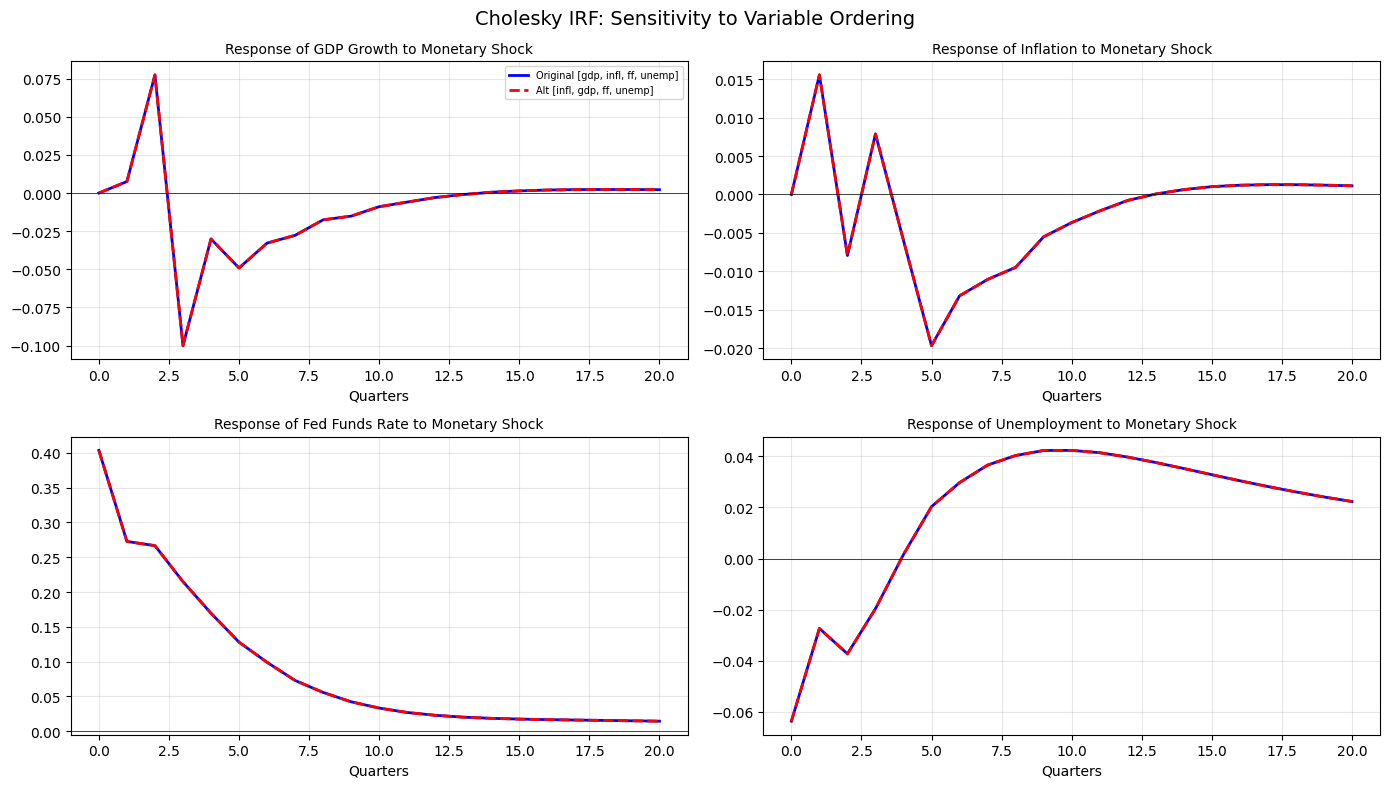

In [15]:
# Compare: Response of GDP to monetary shock under both orderings
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Original: monetary shock is index 2 (fed_funds), GDP is index 0
# Alternative: monetary shock is index 2 (fed_funds), GDP is index 1, inflation is index 0
# Map alt_names indices: inflation=0, gdp=1, fed_funds=2, unemployment=3

var_map_orig = {"gdp": 0, "inflation": 1, "fed_funds": 2, "unemployment": 3}
var_map_alt = {"inflation": 0, "gdp": 1, "fed_funds": 2, "unemployment": 3}

response_vars = ["gdp", "inflation", "fed_funds", "unemployment"]
response_titles = ["GDP Growth", "Inflation", "Fed Funds Rate", "Unemployment"]

for idx, (ax, rv, rt) in enumerate(zip(axes.flat, response_vars, response_titles)):
    # Original ordering
    ax.plot(horizons, irf_cholesky[:, var_map_orig[rv], var_map_orig["fed_funds"]],
            "b-", linewidth=2, label="Original [gdp, infl, ff, unemp]")
    # Alternative ordering
    ax.plot(horizons, irf_alt[:, var_map_alt[rv], var_map_alt["fed_funds"]],
            "r--", linewidth=2, label="Alt [infl, gdp, ff, unemp]")
    ax.axhline(0, color="k", linewidth=0.5)
    ax.set_title(f"Response of {rt} to Monetary Shock", fontsize=10)
    ax.set_xlabel("Quarters")
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7)

plt.suptitle("Cholesky IRF: Sensitivity to Variable Ordering", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "svar_ordering_sensitivity.png"), bbox_inches="tight")
plt.show()

In [16]:
# Quantitative comparison: peak responses and cumulative effects
print("=" * 70)
print("QUANTITATIVE COMPARISON: GDP Response to Monetary Shock")
print("=" * 70)

gdp_resp_orig = irf_cholesky[:, var_map_orig["gdp"], var_map_orig["fed_funds"]]
gdp_resp_alt = irf_alt[:, var_map_alt["gdp"], var_map_alt["fed_funds"]]

print(f"\n{'Metric':<35} {'Original':>12} {'Alternative':>12}")
print("-" * 60)
print(f"{'Impact (h=0)':<35} {gdp_resp_orig[0]:>12.4f} {gdp_resp_alt[0]:>12.4f}")
print(f"{'Peak response':<35} {gdp_resp_orig[np.argmin(gdp_resp_orig)]:>12.4f} {gdp_resp_alt[np.argmin(gdp_resp_alt)]:>12.4f}")
print(f"{'Peak horizon (quarters)':<35} {np.argmin(gdp_resp_orig):>12d} {np.argmin(gdp_resp_alt):>12d}")
print(f"{'Cumulative (20Q)':<35} {np.sum(gdp_resp_orig):>12.4f} {np.sum(gdp_resp_alt):>12.4f}")

print("\n\nConclusion:")
print("The original CEE ordering [gdp, inflation, fed_funds, unemployment] is more")
print("plausible because it reflects the standard timing assumption: GDP and inflation")
print("are predetermined within the quarter relative to monetary policy. The alternative")
print("ordering allows GDP to respond contemporaneously to the monetary shock, which")
print("is implausible at quarterly frequency given information and decision lags.")

QUANTITATIVE COMPARISON: GDP Response to Monetary Shock

Metric                                  Original  Alternative
------------------------------------------------------------
Impact (h=0)                              0.0000       0.0000
Peak response                            -0.1000      -0.1000
Peak horizon (quarters)                        3            3
Cumulative (20Q)                         -0.1935      -0.1935


Conclusion:
The original CEE ordering [gdp, inflation, fed_funds, unemployment] is more
plausible because it reflects the standard timing assumption: GDP and inflation
are predetermined within the quarter relative to monetary policy. The alternative
ordering allows GDP to respond contemporaneously to the monetary shock, which
is implausible at quarterly frequency given information and decision lags.


---

## Exercicio 2: AB Model com restricoes nao-recursivas (SOLUCAO)

Implementamos um modelo AB onde a inflacao responde contemporaneamente tanto ao GDP
quanto ao fed_funds (canal de expectativas), mas o GDP nao responde a nenhuma outra
variavel contemporaneamente.

Restricoes:
- A[0,:] = [1, 0, 0, 0] — GDP exogeno
- A[1,:] = [free, 1, free, 0] — inflacao responde a GDP e fed_funds
- A[2,:] = [free, free, 1, 0] — Taylor rule
- A[3,:] = [free, 0, free, 1] — unemployment responde a GDP e fed_funds
- B = diagonal

In [17]:
# Exercicio 2: AB Model with non-recursive restrictions
A_ex2 = np.array([
    [1.0,     0.0,     0.0,     0.0],   # GDP: exogenous
    [np.nan,  1.0,     np.nan,  0.0],   # Inflation: responds to GDP and fed_funds
    [np.nan,  np.nan,  1.0,     0.0],   # Fed Funds: Taylor rule (GDP, inflation)
    [np.nan,  0.0,     np.nan,  1.0],   # Unemployment: responds to GDP and fed_funds
])

B_ex2 = np.diag([np.nan, np.nan, np.nan, np.nan])

n_free_A = np.isnan(A_ex2).sum()
n_free_B = np.isnan(B_ex2).sum()
n_total_free = n_free_A + n_free_B
n_equations = K * (K + 1) // 2

print(f"Free parameters in A: {n_free_A}")
print(f"Free parameters in B: {n_free_B}")
print(f"Total free parameters: {n_total_free}")
print(f"Available equations: {n_equations}")
print(f"Just-identified: {n_total_free == n_equations}")
print(f"Over-identified: {n_total_free < n_equations}")
print(f"\nNote: {n_equations} - {n_total_free} = {n_equations - n_total_free} excess restrictions")
print("The model is exactly identified (10 free params = 10 equations).")

# Fit the non-recursive AB model
svar_ex2 = SVAR(var_results, method="ab", a_mat=A_ex2, b_mat=B_ex2)
results_ex2 = svar_ex2.fit()

print(f"\nEstimated A matrix (non-recursive):")
print(pd.DataFrame(results_ex2.A0.round(4), index=var_names, columns=var_names))
print(f"\nEstimated B matrix:")
print(pd.DataFrame(results_ex2.B.round(4), index=var_names, columns=var_names))
print(f"\nStructural impact matrix (A^{{-1}}B):")
print(pd.DataFrame(
    results_ex2.A0_inv.round(4),
    index=var_names, columns=[f"shock_{v}" for v in var_names]
))

Free parameters in A: 6
Free parameters in B: 4
Total free parameters: 10
Available equations: 10
Just-identified: True
Over-identified: False

Note: 10 - 10 = 0 excess restrictions
The model is exactly identified (10 free params = 10 equations).



Estimated A matrix (non-recursive):
                 gdp  inflation  fed_funds  unemployment
gdp           1.0000     0.0000     0.0000           0.0
inflation    -0.1231     1.0000     0.0165           0.0
fed_funds     0.0295    -0.0972     1.0000           0.0
unemployment  0.1579     0.0000     0.1343           1.0

Estimated B matrix:
                 gdp  inflation  fed_funds  unemployment
gdp           0.6662     0.0000     0.0000        0.0000
inflation     0.0000     0.4963     0.0000        0.0000
fed_funds     0.0000     0.0000     0.4035        0.0000
unemployment  0.0000     0.0000     0.0000        0.2861

Structural impact matrix (A^{-1}B):
              shock_gdp  shock_inflation  shock_fed_funds  shock_unemployment
gdp              0.6662           0.0000           0.0000              0.0000
inflation        0.0822           0.4955          -0.0067              0.0000
fed_funds       -0.0117           0.0482           0.4029              0.0000
unemployment    -0.1036

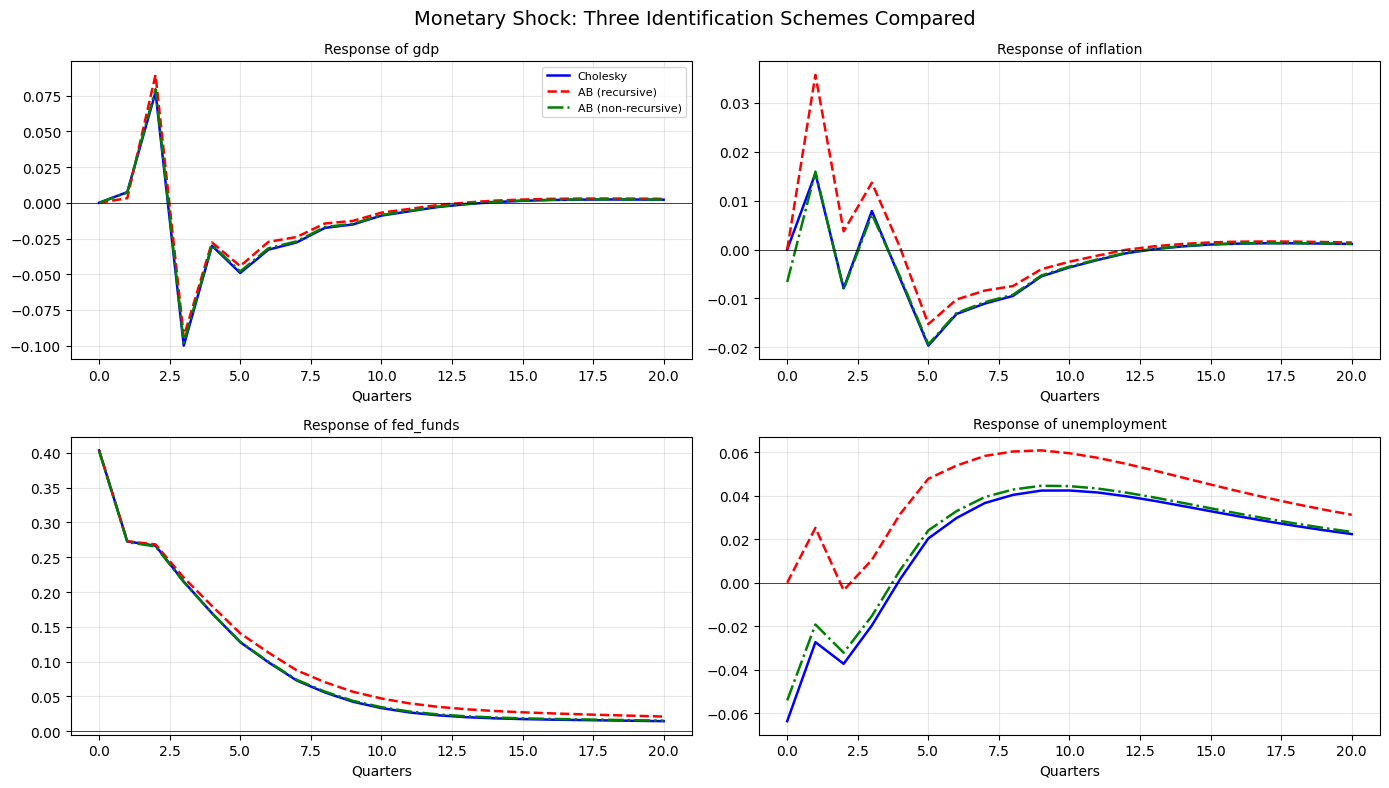

In [18]:
# Compare IRFs: Cholesky vs AB (recursive) vs AB (non-recursive)
irf_ex2 = results_ex2.irf(periods=20)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (ax, name, title) in enumerate(zip(axes.flat, var_names, titles)):
    ax.plot(horizons, irf_cholesky[:, i, monetary_shock_idx],
            "b-", linewidth=1.8, label="Cholesky")
    ax.plot(horizons, irf_ab[:, i, monetary_shock_idx],
            "r--", linewidth=1.8, label="AB (recursive)")
    ax.plot(horizons, irf_ex2[:, i, monetary_shock_idx],
            "g-.", linewidth=1.8, label="AB (non-recursive)")
    ax.axhline(0, color="k", linewidth=0.5)
    ax.set_title(f"Response of {name}", fontsize=10)
    ax.set_xlabel("Quarters")
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle("Monetary Shock: Three Identification Schemes Compared", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "svar_three_schemes_comparison.png"), bbox_inches="tight")
plt.show()

In [19]:
# Quantitative comparison across all three identification schemes
print("=" * 80)
print("QUANTITATIVE COMPARISON: Monetary Policy Shock across Identification Schemes")
print("=" * 80)

schemes = {
    "Cholesky": irf_cholesky,
    "AB (recursive)": irf_ab,
    "AB (non-recursive)": irf_ex2,
}

comparison_data = []
for scheme_name, irf_data in schemes.items():
    for var_idx, vname in enumerate(var_names):
        resp = irf_data[:, var_idx, monetary_shock_idx]
        comparison_data.append({
            "Scheme": scheme_name,
            "Variable": vname,
            "Impact (h=0)": resp[0],
            "Peak response": resp[np.argmax(np.abs(resp))],
            "Peak horizon": int(np.argmax(np.abs(resp))),
            "Cumulative (20Q)": np.sum(resp),
            "Half-life (quarters)": int(np.argmax(np.abs(resp) < np.abs(resp).max() * 0.5)) if np.abs(resp).max() > 0 else 0,
        })

df_comparison = pd.DataFrame(comparison_data)
print("\n")
for vname in var_names:
    print(f"\n--- {vname.upper()} ---")
    subset = df_comparison[df_comparison["Variable"] == vname].set_index("Scheme")
    print(subset.drop(columns=["Variable"]).round(4).to_string())

print("\n\nKey differences:")
print("- The non-recursive AB model allows inflation to respond to fed_funds shocks")
print("  contemporaneously, unlike the recursive models. This can affect the 'price puzzle'.")
print("- The non-recursive model also allows unemployment to respond to monetary shocks")
print("  within the quarter, reflecting faster labor market adjustment.")

QUANTITATIVE COMPARISON: Monetary Policy Shock across Identification Schemes



--- GDP ---
                    Impact (h=0)  Peak response  Peak horizon  Cumulative (20Q)  Half-life (quarters)
Scheme                                                                                               
Cholesky                     0.0        -0.1000             3           -0.1935                     0
AB (recursive)               0.0        -0.0938             3           -0.1457                     0
AB (non-recursive)           0.0        -0.0980             3           -0.1832                     0

--- INFLATION ---
                    Impact (h=0)  Peak response  Peak horizon  Cumulative (20Q)  Half-life (quarters)
Scheme                                                                                               
Cholesky                  0.0000        -0.0197             5           -0.0481                     0
AB (recursive)            0.0000         0.0357             1            

---

## 6. Save Outputs

Save the structural IRF and estimated B matrix for cross-validation.

In [20]:
# Save structural IRF from Cholesky identification to CSV
# Reshape IRF to a 2D table: rows = (horizon, response_var), columns = shocks
irf_rows = []
for h in range(irf_cholesky.shape[0]):
    for i, vname in enumerate(var_names):
        row = {"horizon": h, "response_variable": vname}
        for j, sname in enumerate(shock_names):
            row[sname] = irf_cholesky[h, i, j]
        irf_rows.append(row)

df_irf = pd.DataFrame(irf_rows)
irf_path = os.path.join("..", "outputs", "svar_irf_cholesky.csv")
df_irf.to_csv(irf_path, index=False, float_format="%.6f")
print(f"Saved Cholesky IRF to {irf_path}")
print(f"Shape: {df_irf.shape}")
print(f"\nFirst 8 rows:")
df_irf.head(8)

Saved Cholesky IRF to ../outputs/svar_irf_cholesky.csv
Shape: (84, 6)

First 8 rows:


,horizon,response_variable,GDP shock,Inflation shock,Monetary shock,Unemp. shock
0,0,gdp,0.666189,0.000000,0.000000,0.000000
1,0,inflation,0.082201,0.495561,0.000000,0.000000
2,0,fed_funds,-0.011670,0.042759,0.403466,0.000000
3,0,unemployment,-0.103624,0.083350,-0.063633,0.271728
4,1,gdp,0.275630,-0.024927,0.007518,-0.018326
5,1,inflation,0.072199,0.222809,0.015551,0.086041
6,1,fed_funds,0.092290,0.070571,0.272646,0.001361
7,1,unemployment,-0.161126,0.049878,-0.027348,0.224344


In [21]:
# Save estimated B matrix (structural impact matrix) to JSON
b_matrix_data = {
    "method": "cholesky",
    "description": "Structural impact matrix B0_inv from Cholesky identification",
    "variable_names": var_names,
    "shock_names": shock_names,
    "B0_inv": results_cholesky.A0_inv.tolist(),
    "B0_inv_ab_model": results_ab.A0_inv.tolist(),
    "A_matrix_ab": results_ab.A0.tolist(),
    "B_matrix_ab": results_ab.B.tolist(),
    "sigma_u": var_results.sigma_u.tolist(),
    "reconstruction_error_cholesky": float(np.linalg.norm(
        var_results.sigma_u - results_cholesky.A0_inv @ results_cholesky.A0_inv.T
    )),
    "n_obs": int(var_results.nobs),
    "n_lags": int(var_results.k_ar),
    "comparison": {
        "cholesky_impact_diagonal": np.diag(results_cholesky.A0_inv).tolist(),
        "ab_model_B_diagonal": np.diag(results_ab.B).tolist(),
    }
}

b_matrix_path = os.path.join("..", "outputs", "svar_B_matrix.json")
with open(b_matrix_path, "w") as f:
    json.dump(b_matrix_data, f, indent=2)

print(f"Saved B matrix data to {b_matrix_path}")
print(f"\nB0_inv (Cholesky):")
print(pd.DataFrame(results_cholesky.A0_inv.round(4), index=var_names, columns=shock_names))
print(f"\nA matrix (AB model):")
print(pd.DataFrame(results_ab.A0.round(4), index=var_names, columns=var_names))
print(f"\nB matrix (AB model):")
print(pd.DataFrame(results_ab.B.round(4), index=var_names, columns=var_names))

Saved B matrix data to ../outputs/svar_B_matrix.json

B0_inv (Cholesky):
              GDP shock  Inflation shock  Monetary shock  Unemp. shock
gdp              0.6662           0.0000          0.0000        0.0000
inflation        0.0822           0.4956          0.0000        0.0000
fed_funds       -0.0117           0.0428          0.4035        0.0000
unemployment    -0.1036           0.0833         -0.0636        0.2717

A matrix (AB model):
                 gdp  inflation  fed_funds  unemployment
gdp           1.0000     0.0000        0.0           0.0
inflation    -0.1234     1.0000        0.0           0.0
fed_funds     0.0282    -0.0863        1.0           0.0
unemployment  0.1555     0.0000        0.0           1.0

B matrix (AB model):
                 gdp  inflation  fed_funds  unemployment
gdp           0.6662     0.0000     0.0000        0.0000
inflation     0.0000     0.4956     0.0000        0.0000
fed_funds     0.0000     0.0000     0.4035        0.0000
unemployment  0

---

## Resumo

Neste notebook resolvemos completamente:

1. **Cholesky identification**: IRFs estruturais, FEVD, choques recuperados
2. **AB model**: restricoes recursivas e nao-recursivas
3. **Exercicio 1**: Comparacao de orderings (CEE vs cost-push) — a ordenacao CEE
   e mais plausivel economicamente
4. **Exercicio 2**: AB model nao-recursivo com inflacao respondendo a fed_funds
   contemporaneamente — 10 parametros livres = 10 equacoes (exatamente identificado)
5. **Comparacao quantitativa**: peak responses, cumulative effects, half-lives
   across Cholesky, AB recursivo, e AB nao-recursivo

### Outputs salvos:
- `outputs/svar_irf_cholesky.csv` — IRF estrutural completa
- `outputs/svar_B_matrix.json` — Matrizes A e B estimadas